In [1]:
config = {
    "reference": {
                "tag": "Apple",
           "filename": "../ActiGraph data/csv/0001_acti.csv",
         "start_time": "10/11/2024 13:40:00.000",
           "end_time": "10/11/2024 14:59:00.000",
        "time_format": "%m/%d/%Y %H:%M:%S.%f",
             "window": "10T",
          "time_zone": 'US/Eastern'
    },
    "target": {
                "tag": "Pixel",
           "filename": "../Pixel/Accel.csv",
         "start_time": 1728667671888,
           "end_time": 1728678613466,
        "time_format": "ms",
             "window": "10T",
          "time_zone": 'US/Eastern'
    },
    "output": {
           "filename": "../Pixel/Accel_realigned_1.csv"
    }
}

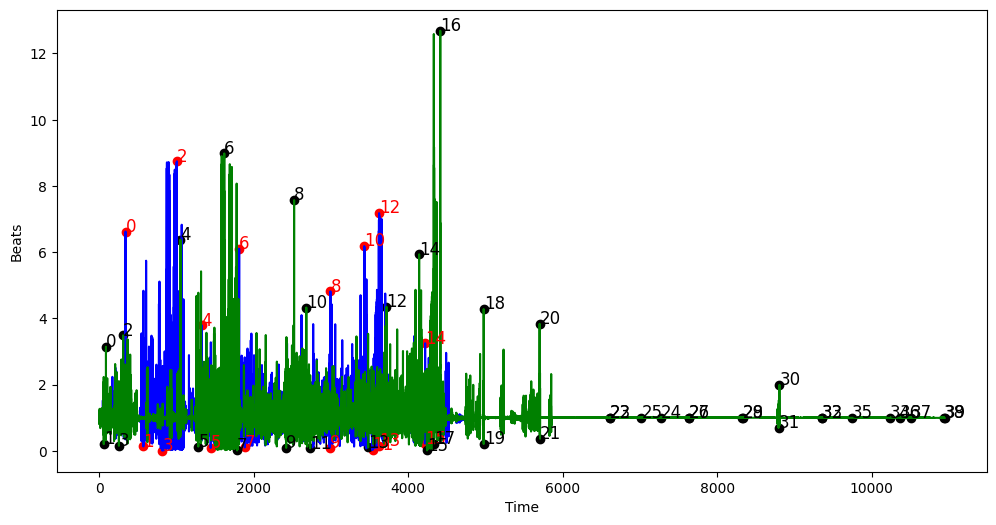

In [2]:
from aligner import DataSeries
import matplotlib.pyplot as plt

fig1, ax1 = plt.subplots(figsize=(12, 6), dpi=100)

ds1 = DataSeries(config["reference"], line_color="blue", label_color="red")
ds1.load_actigraph()
ds1.plot_relative(ax1)

ds2 = DataSeries(config["target"], line_color="green", label_color="black")
ds2.load_pixel_accel()
ds2.plot_relative(ax1)

plt.show()

Choose aligning points [blue, green] (e.g, 10,9):  10,14


10 14


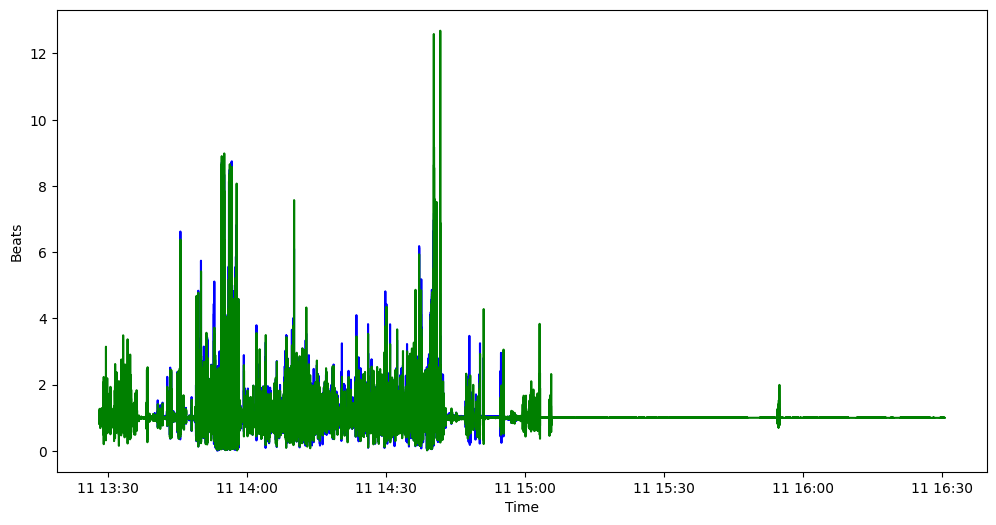

In [3]:
user_input = input("Choose aligning points [blue, green] (e.g, 10,9): ")
tokens = user_input.split(',')
    
point1 = int(tokens[0])
point2 = int(tokens[1])

ds1.align_point = point1
ds2.align_point = point2

print(point1, point2)

fig2, ax2 = plt.subplots(figsize=(12, 6), dpi=100)


ref_time = ds1.get_ref_time()
ds2.re_align(ref_time)

ds1.plot_absolute(ax2)
ds2.plot_absolute(ax2)


plt.show()

In [4]:
filename = config["output"]["filename"]
ds2.accel2csv(filename)
print("Successfully save file to %s" % filename)

Successfully save file to ../Pixel/Accel_realigned_1.csv
